<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); color: white; padding: 40px; margin: -10px -10px 20px -10px; border-radius: 0 0 15px 15px;">
<h1 style="margin: 0; font-size: 2.5em;">Superconducting Materials for Electronics</h1>
<p style="margin: 10px 0 0 0; font-size: 1.2em; opacity: 0.9;">Week 1, Session 2 — SCE Futures</p>
</div>

## Contents

- [Learning Objectives](#learning-objectives)

1. [Low-Temperature Superconductors (LTS)](#1-lts)
2. [Why Niobium Dominates SCE](#2-why-niobium)
3. [The Nb/Al-AlOx/Nb Trilayer](#3-trilayer)
4. [Material Properties Comparison](#4-comparison)
5. [High-Temperature Superconductors (HTS)](#5-hts)
6. [Material Selection Criteria](#6-selection)

---
<a id="learning-objectives"></a>
## Learning Objectives

By the end of this session, you will be able to:

- Compare the key properties of LTS materials (Nb, NbN, NbTiN, Al)
- Explain why niobium is the dominant material for superconducting electronics
- Describe the structure and physics of the Nb/Al-AlOx/Nb trilayer junction
- Calculate material parameters from fundamental constants
- Match superconducting materials to appropriate applications
- Understand the challenges of using high-temperature superconductors

---

In [1]:
# Setup: Import libraries for visualizations and calculations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle
from matplotlib.lines import Line2D
import numpy as np

# Color scheme (consistent with course materials)
COLORS = {
    'primary': '#2196F3',      # Blue
    'secondary': '#FF9800',    # Orange
    'success': '#4CAF50',      # Green
    'danger': '#f44336',       # Red
    'dark': '#1a1a2e',         # Dark blue
    'light': '#f5f5f5',        # Light gray
    'superconducting': '#00BCD4',  # Cyan
    'normal': '#9E9E9E',       # Gray
    'nb': '#5C6BC0',           # Indigo (Niobium)
    'nbn': '#7E57C2',          # Purple (NbN)
    'nbtin': '#AB47BC',        # Magenta (NbTiN)
    'al': '#26A69A',           # Teal (Aluminum)
    'hts': '#EF5350'           # Red (HTS)
}

# Physical constants
k_B = 8.617333262e-5   # Boltzmann constant (eV/K)
h = 6.62607015e-34     # Planck constant (J·s)
e = 1.602176634e-19    # Elementary charge (C)
Phi_0 = h / (2 * e)    # Flux quantum (Wb)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

print("Setup complete.")
print(f"Flux quantum: {Phi_0:.6e} Wb")
print(f"Boltzmann constant: {k_B:.6e} eV/K")

Setup complete.
Flux quantum: 2.067834e-15 Wb
Boltzmann constant: 8.617333e-05 eV/K


---
<a id="1-lts"></a>
# 1. Low-Temperature Superconductors (LTS)
---

Low-temperature superconductors are materials with critical temperatures typically below 30 K, operating at liquid helium temperatures (4.2 K). They form the backbone of superconducting electronics due to their **predictable BCS behavior**, **mature fabrication processes**, and **high-quality Josephson junctions**.

### The LTS Family for Electronics

Four materials dominate modern superconducting electronics:

| Material | T_c (K) | 2Δ (meV) | λ (nm) | ξ (nm) | Primary Application |
|----------|---------|----------|--------|--------|---------------------|
| **Nb** | 9.2 | 3.0 | 90 | 38 | Digital logic, RSFQ, AQFP |
| **NbN** | 16 | 5.0 | 200 | 5 | Photon detectors (SNSPDs) |
| **NbTiN** | 15+ | 4.8 | 250 | 5 | Kinetic inductance devices |
| **Al** | 1.2 | 0.34 | 50 | 1600 | Superconducting qubits |

## 1.1 Niobium (Nb) — The Workhorse of SCE

Niobium is the **highest-Tc elemental superconductor** and forms the foundation of superconducting electronics:

| Property | Value | Significance |
|----------|-------|-------------|
| Critical temperature T_c | **9.2 K** | Highest for any element |
| Energy gap 2Δ | **3.0 meV** | Large gap → robust operation at 4.2 K |
| Penetration depth λ | **90 nm** | Moderate, good for thin films |
| Coherence length ξ | **38 nm** | Large → clean junctions |
| Crystal structure | BCC | Easy to deposit high-quality films |
| Native oxide | Nb₂O₅ | Stable, protective |

### Why 9.2 K Matters

Operating at 4.2 K means T/T_c ≈ 0.46, well into the superconducting regime:
- Thermal excitations ~k_BT = 0.36 meV << 2Δ = 3.0 meV
- Quasiparticle density exponentially suppressed: n_qp ∝ exp(-Δ/k_BT)
- Junction critical current essentially at T=0 value

In [2]:
# Calculate Nb parameters and thermal margins
Tc_Nb = 9.2  # K
T_op = 4.2   # K (liquid helium)

# BCS energy gap (weak coupling: 2Δ = 3.53 k_B T_c)
Delta_0_BCS = 1.764 * k_B * Tc_Nb  # Single gap Δ
two_Delta_BCS = 2 * Delta_0_BCS

# Experimental value for Nb (slightly higher than weak-coupling BCS)
two_Delta_Nb = 3.0e-3  # eV = 3.0 meV (experimental)

# Thermal energy at operating temperature
E_thermal = k_B * T_op  # eV

# Gap ratio (thermal margin)
gap_ratio = (two_Delta_Nb / 2) / E_thermal

print("="*60)
print("NIOBIUM (Nb) — Key Parameters")
print("="*60)
print(f"")
print(f"Critical temperature:     T_c  = {Tc_Nb} K")
print(f"Operating temperature:    T_op = {T_op} K")
print(f"Temperature ratio:        T/T_c = {T_op/Tc_Nb:.2f}")
print(f"")
print(f"Energy gap (BCS theory):  2Δ = {two_Delta_BCS*1e3:.2f} meV")
print(f"Energy gap (experimental): 2Δ = {two_Delta_Nb*1e3:.2f} meV")
print(f"Gap ratio 2Δ/k_BT_c:      {two_Delta_Nb/(k_B*Tc_Nb):.2f} (BCS: 3.53)")
print(f"")
print(f"Thermal energy at 4.2K:   k_BT = {E_thermal*1e3:.3f} meV")
print(f"Gap/thermal ratio:        Δ/k_BT = {gap_ratio:.1f}")
print(f"")
print(f"Characteristic frequency: f_gap = 2Δ/h = {two_Delta_Nb*e/h/1e9:.0f} GHz")

NIOBIUM (Nb) — Key Parameters

Critical temperature:     T_c  = 9.2 K
Operating temperature:    T_op = 4.2 K
Temperature ratio:        T/T_c = 0.46

Energy gap (BCS theory):  2Δ = 2.80 meV
Energy gap (experimental): 2Δ = 3.00 meV
Gap ratio 2Δ/k_BT_c:      3.78 (BCS: 3.53)

Thermal energy at 4.2K:   k_BT = 0.362 meV
Gap/thermal ratio:        Δ/k_BT = 4.1

Characteristic frequency: f_gap = 2Δ/h = 725 GHz


## 1.2 Niobium Nitride (NbN) — High Kinetic Inductance

NbN is a **disordered superconductor** with unique properties that make it ideal for detectors:

| Property | Value | Comparison to Nb |
|----------|-------|------------------|
| Critical temperature T_c | **16 K** | 1.7× higher |
| Energy gap 2Δ | **5.0 meV** | 1.7× larger |
| Penetration depth λ | **200 nm** | 5× longer |
| Coherence length ξ | **5 nm** | 8× shorter |
| GL parameter κ | **40** | Type II, deep in dirty limit |
| Sheet kinetic inductance | **~1 pH/□** | High, tunable |

### Why NbN for Detectors?

1. **High kinetic inductance**: L_k = μ₀λ² × (length/width×thickness)
   - Small signal → large inductance change → easier detection
   
2. **Fast electron-phonon relaxation**: ~10-20 ps
   - Enables GHz-rate single-photon detection
   
3. **Large energy gap**: Photon detection from UV to IR

4. **Thin films**: 4-10 nm thick films for superconducting nanowire single-photon detectors (SNSPDs)

## 1.3 Niobium Titanium Nitride (NbTiN) — Tunable Properties

NbTiN is a **ternary compound** with properties intermediate between NbN and TiN, offering tunability:

| Property | Value Range | Control Method |
|----------|-------------|----------------|
| Critical temperature T_c | **9-16 K** | Ti/Nb ratio |
| Energy gap 2Δ | **3-5 meV** | Composition |
| Penetration depth λ | **200-400 nm** | Disorder |
| Sheet resistance R_□ | **10-100 Ω/□** | Thickness, composition |

### Applications

1. **Kinetic Inductance Detectors (KIDs)**
   - Microwave resonators where photon absorption changes kinetic inductance
   - Astronomy: CMB polarimetry, submillimeter surveys
   
2. **Traveling-Wave Parametric Amplifiers (TWPAs)**
   - Nonlinear kinetic inductance enables parametric amplification
   - Quantum-limited noise performance

3. **Hot-Electron Bolometers**
   - THz detection for radio astronomy

## 1.4 Aluminum (Al) — The Qubit Material

Despite its **low T_c**, aluminum has become the material of choice for superconducting qubits:

| Property | Value | Significance |
|----------|-------|-------------|
| Critical temperature T_c | **1.2 K** | Low but sufficient at 10-20 mK |
| Energy gap 2Δ | **0.34 meV** | ~80 GHz → microwave regime |
| Penetration depth λ | **50 nm** | Moderate |
| Coherence length ξ | **1600 nm** | Very long! |
| Native oxide | **Al₂O₃** | Self-limiting, reproducible barriers |

### Why Aluminum for Qubits?

1. **Low TLS defect density**: Amorphous Al₂O₃ has among the lowest two-level system (TLS) losses
   - TLS cause decoherence in qubits
   - Al/AlOx interfaces are cleaner than most alternatives

2. **Self-limiting oxidation**: Al₂O₃ barrier thickness is highly reproducible
   - Critical for qubit junction consistency
   
3. **Long coherence length**: ξ = 1600 nm means:
   - Junction behavior averages over many atoms
   - Less sensitive to local defects
   
4. **Dilution refrigerator operation**: At 10-20 mK, T/T_c ≈ 0.01
   - Quasiparticle density is vanishingly small

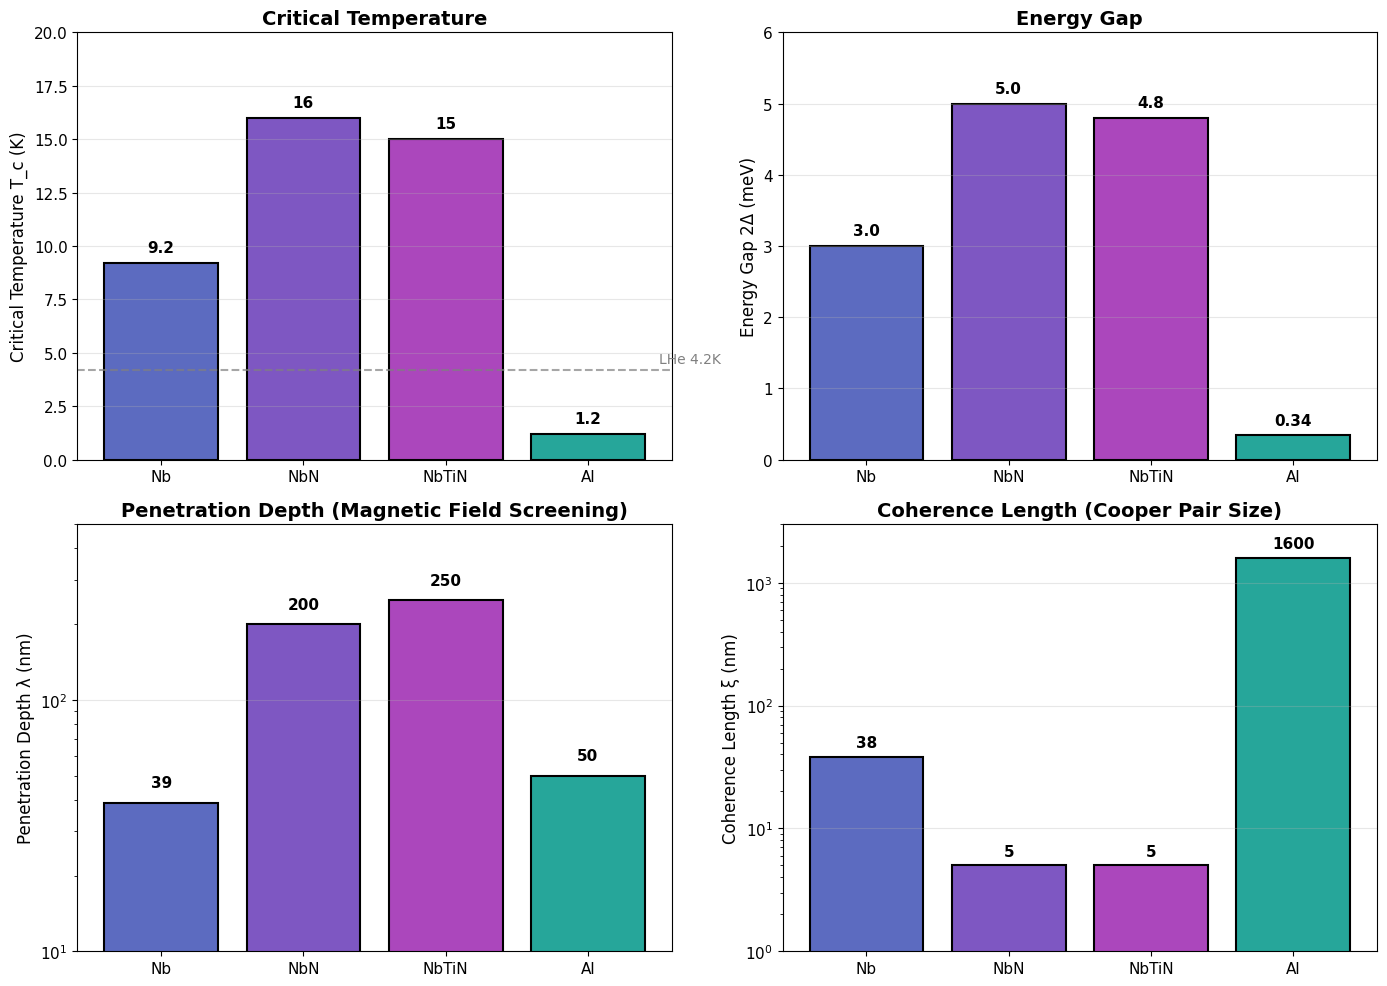

Key observations:
  - NbN/NbTiN: High T_c, large gap, HIGH λ (kinetic inductance), SHORT ξ (disorder)
  - Nb: Best balance of properties for Josephson junctions
  - Al: Very LONG ξ → cleaner junctions, less TLS sensitivity


In [3]:
# Visualize LTS material comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

materials = ['Nb', 'NbN', 'NbTiN', 'Al']
colors = [COLORS['nb'], COLORS['nbn'], COLORS['nbtin'], COLORS['al']]

# Data for each material
Tc_values = [9.2, 16, 15, 1.2]  # K
gap_values = [3.0, 5.0, 4.8, 0.34]  # meV
lambda_values = [39, 200, 250, 50]  # nm
xi_values = [38, 5, 5, 1600]  # nm

# Plot 1: Critical Temperature
ax = axes[0, 0]
bars = ax.bar(materials, Tc_values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Critical Temperature T_c (K)', fontsize=12)
ax.set_title('Critical Temperature', fontsize=14, fontweight='bold')
ax.axhline(y=4.2, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(3.5, 4.5, 'LHe 4.2K', fontsize=10, color='gray')
ax.set_ylim(0, 20)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, Tc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val}', ha='center', fontsize=11, fontweight='bold')

# Plot 2: Energy Gap
ax = axes[0, 1]
bars = ax.bar(materials, gap_values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Energy Gap 2Δ (meV)', fontsize=12)
ax.set_title('Energy Gap', fontsize=14, fontweight='bold')
ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, gap_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, 
            f'{val}', ha='center', fontsize=11, fontweight='bold')

# Plot 3: Penetration Depth (log scale)
ax = axes[1, 0]
bars = ax.bar(materials, lambda_values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Penetration Depth λ (nm)', fontsize=12)
ax.set_title('Penetration Depth (Magnetic Field Screening)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.set_ylim(10, 500)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, lambda_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15, 
            f'{val}', ha='center', fontsize=11, fontweight='bold')

# Plot 4: Coherence Length (log scale)
ax = axes[1, 1]
bars = ax.bar(materials, xi_values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Coherence Length ξ (nm)', fontsize=12)
ax.set_title('Coherence Length (Cooper Pair Size)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.set_ylim(1, 3000)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, xi_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.2, 
            f'{val}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - NbN/NbTiN: High T_c, large gap, HIGH λ (kinetic inductance), SHORT ξ (disorder)")
print("  - Nb: Best balance of properties for Josephson junctions")
print("  - Al: Very LONG ξ → cleaner junctions, less TLS sensitivity")

---
<a id="2-why-niobium"></a>
# 2. Why Niobium Dominates SCE
---

Niobium is the **workhorse of superconducting electronics** for several compelling reasons:

### 2.1 Highest Elemental T_c

At **9.2 K**, niobium is the elemental superconductor with the highest critical temperature:

| Element | T_c (K) | Why Not Used? |
|---------|---------|---------------|
| Nb | **9.2** | **The choice!** |
| V | 5.4 | Lower T_c, reactive |
| Ta | 4.5 | Lower T_c |
| Pb | 7.2 | Soft, Type I |
| Al | 1.2 | Too low for most digital |

This matters because:
- **Large thermal margin** at 4.2 K (liquid helium)
- **Robust against temperature fluctuations**
- **Higher gap frequency** → faster switching

### 2.2 Mature Fabrication Technology

Decades of development have produced reliable Nb processes:

| Process Aspect | Capability | Significance |
|----------------|------------|---------------|
| Film deposition | Sputtered, high-quality | Consistent T_c, low defects |
| Patterning | Standard photolithography | Sub-micron features |
| Etching | RIE with CF₄/O₂ | Clean, vertical sidewalls |
| Multilayer | 10+ metal layers | Complex circuits |
| Junctions | Nb/Al-AlOx/Nb trilayer | Reproducible I_c |

**Foundry processes** are available:
- MIT Lincoln Laboratory (SFQ5ee)
- HYPRES
- AIST (Japan)
- Several others worldwide

### 2.3 Excellent I_cR_n Product

The **characteristic voltage** V_c = I_cR_n is a key figure of merit for Josephson junctions:

$$V_c = I_c R_n \approx \frac{\pi \Delta}{2e} \approx \frac{\pi}{4} \times 2\Delta$$

For Nb/Al-AlOx/Nb junctions:

| Parameter | Typical Value |
|-----------|---------------|
| Gap voltage | 2Δ/e ≈ 2.8-3.0 mV |
| I_cR_n product | **1.7-1.9 mV** |
| Josephson frequency at V_c | ~800 GHz |

**Why this matters**:
- Higher V_c → faster switching
- V_c sets the maximum clock frequency
- Critical current × normal resistance = speed × signal amplitude

In [4]:
# Calculate I_cR_n product for Nb junction
Delta_Nb = 1.5e-3  # eV (Δ = 1.5 meV)
two_Delta_Nb = 3.0e-3  # eV (2Δ = 3.0 meV)

# Ambegaokar-Baratoff relation: I_c R_n = (π/4) × (2Δ/e) for SIS junction at T=0
V_gap = two_Delta_Nb / 1  # Gap voltage in V (since Δ is in eV, divide by e=1 in natural units)
IcRn_theoretical = (np.pi / 4) * V_gap  # in V

# Experimental values
IcRn_typical = 1.8e-3  # 1.8 mV typical

print("="*60)
print("Nb JOSEPHSON JUNCTION — I_cR_n Product")
print("="*60)
print(f"")
print(f"Gap voltage:              2Δ/e = {two_Delta_Nb*1e3:.1f} mV")
print(f"Theoretical I_cR_n:       (π/4)×(2Δ/e) = {IcRn_theoretical*1e3:.2f} mV")
print(f"Typical experimental:     {IcRn_typical*1e3:.1f} mV")
print(f"")
print(f"Josephson frequency at V_c:")
f_J = IcRn_typical / Phi_0
print(f"  f_J = V/Φ₀ = {f_J/1e9:.0f} GHz")
print(f"")
print(f"This high I_cR_n enables:")
print(f"  - RSFQ clock rates up to 100+ GHz")
print(f"  - Fast SFQ pulse propagation")
print(f"  - Large signal margins")

Nb JOSEPHSON JUNCTION — I_cR_n Product

Gap voltage:              2Δ/e = 3.0 mV
Theoretical I_cR_n:       (π/4)×(2Δ/e) = 2.36 mV
Typical experimental:     1.8 mV

Josephson frequency at V_c:
  f_J = V/Φ₀ = 870 GHz

This high I_cR_n enables:
  - RSFQ clock rates up to 100+ GHz
  - Fast SFQ pulse propagation
  - Large signal margins


### 2.4 Chemical Stability

Niobium forms a stable, protective oxide (Nb₂O₅) that:

1. **Prevents further oxidation** — Self-limiting at ~5 nm
2. **Enables air handling** — Wafers can be processed in clean room air
3. **Provides insulation** — Native oxide is used as dielectric in some designs

Compared to alternatives:
- NbN: Requires careful deposition, sensitive to oxygen
- YBCO: Highly reactive, needs protective layers
- MgB₂: Air-sensitive

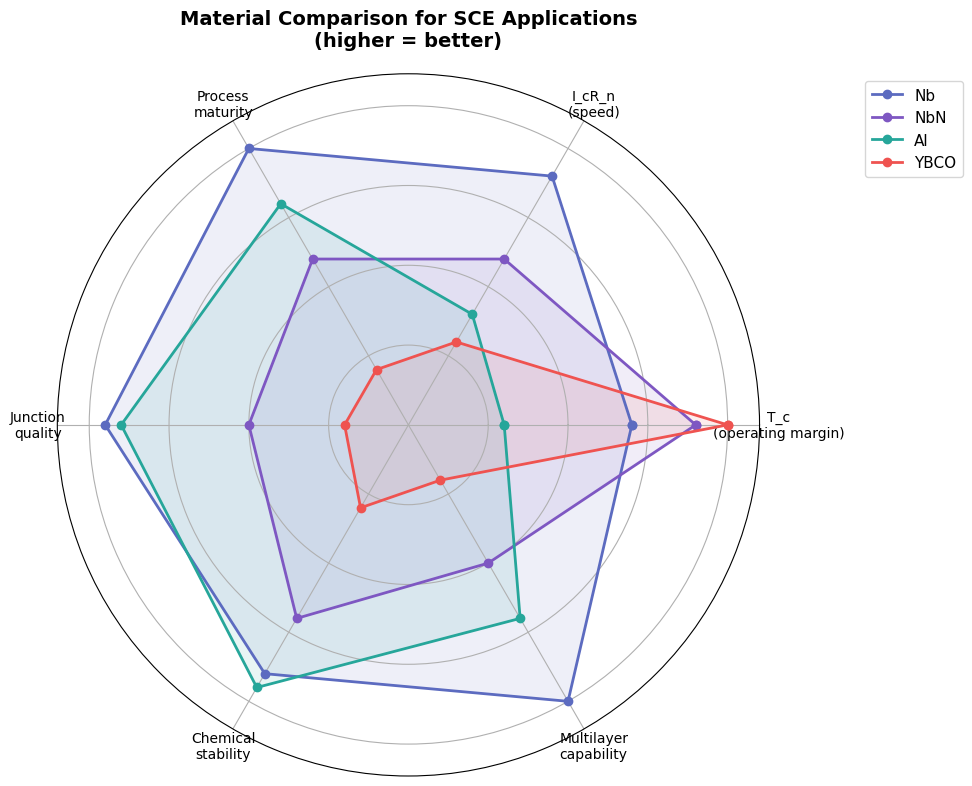

Nb dominates because it scores high across ALL categories relevant to digital SCE.


In [5]:
# Visualize why Nb dominates: radar chart of properties
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

# Categories (normalized 0-1, higher is better for SCE applications)
categories = ['T_c\n(operating margin)', 'I_cR_n\n(speed)', 'Process\nmaturity', 
              'Junction\nquality', 'Chemical\nstability', 'Multilayer\ncapability']
N = len(categories)

# Scores for each material (0-1 scale)
scores = {
    'Nb': [0.7, 0.9, 1.0, 0.95, 0.9, 1.0],
    'NbN': [0.9, 0.6, 0.6, 0.5, 0.7, 0.5],
    'Al': [0.3, 0.4, 0.8, 0.9, 0.95, 0.7],
    'YBCO': [1.0, 0.3, 0.2, 0.2, 0.3, 0.2]
}

# Angles for each category
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Complete the loop

# Plot each material
for material, score in scores.items():
    values = score + score[:1]  # Complete the loop
    color = {'Nb': COLORS['nb'], 'NbN': COLORS['nbn'], 'Al': COLORS['al'], 'YBCO': COLORS['hts']}[material]
    ax.plot(angles, values, 'o-', linewidth=2, label=material, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['', '', '', ''], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.set_title('Material Comparison for SCE Applications\n(higher = better)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("Nb dominates because it scores high across ALL categories relevant to digital SCE.")

---
<a id="3-trilayer"></a>
# 3. The Nb/Al-AlOx/Nb Trilayer
---

The **Nb/Al-AlOx/Nb trilayer** is the standard Josephson junction structure for superconducting electronics. It represents one of the most significant achievements in superconductor technology.

### 3.1 Structure Overview

```
     ┌──────────────────────────┐
     │       Nb (top, ~200nm)   │  ← Superconducting electrode
     ├──────────────────────────┤
     │     AlOx (~0.8-1.9nm)    │  ← Tunnel barrier
     ├──────────────────────────┤
     │    Al (wetting, ~7nm)    │  ← Wetting/proximity layer
     ├──────────────────────────┤
     │     Nb (bottom, ~200nm)  │  ← Superconducting electrode
     └──────────────────────────┘
```

| Layer | Thickness | Function |
|-------|-----------|----------|
| Nb (bottom) | 150-200 nm | Base superconducting electrode |
| Al (wetting) | 6-8 nm | Provides uniform oxide, proximized |
| AlOx (barrier) | 0.8-1.9 nm | Tunnel barrier, sets J_c |
| Nb (top) | 150-200 nm | Counter superconducting electrode |

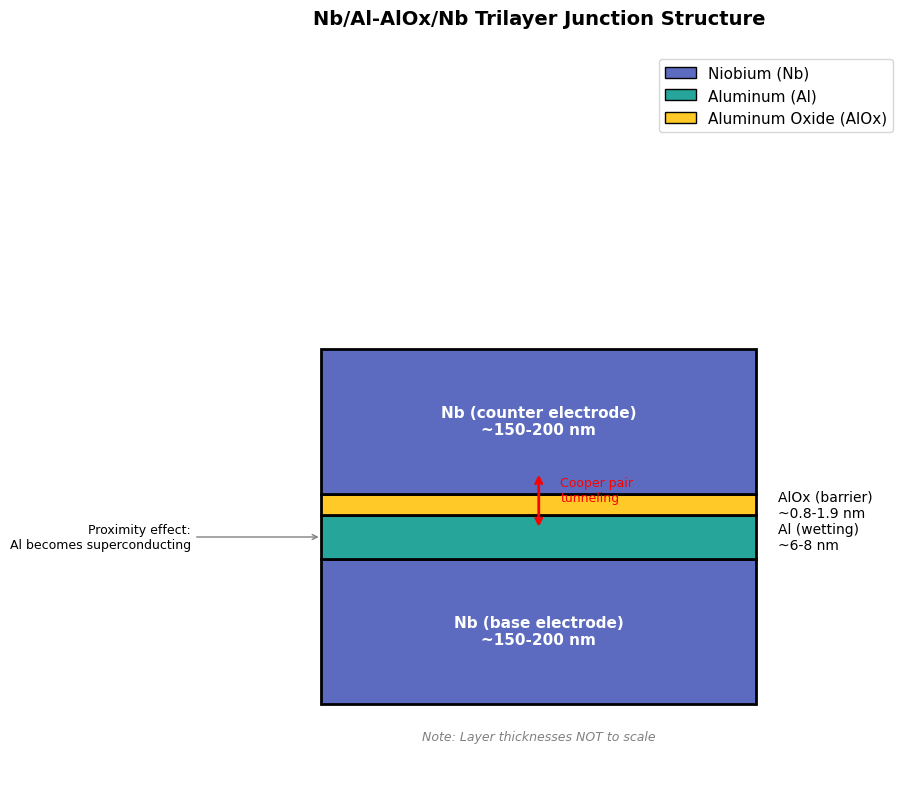

In [6]:
# Visualize trilayer structure
fig, ax = plt.subplots(figsize=(12, 8))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

# Colors
nb_color = '#5C6BC0'  # Indigo for Nb
al_color = '#26A69A'  # Teal for Al
alox_color = '#FFCA28'  # Amber for AlOx

# Draw layers (to scale would be impossible, so use representative thicknesses)
layer_width = 6
x_start = 2

# Bottom Nb
rect = Rectangle((x_start, 1), layer_width, 2, facecolor=nb_color, edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(x_start + layer_width/2, 2, 'Nb (base electrode)\n~150-200 nm', ha='center', va='center', 
        fontsize=11, fontweight='bold', color='white')

# Al wetting layer
rect = Rectangle((x_start, 3), layer_width, 0.6, facecolor=al_color, edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(x_start + layer_width + 0.3, 3.3, 'Al (wetting)\n~6-8 nm', ha='left', va='center', fontsize=10)

# AlOx tunnel barrier
rect = Rectangle((x_start, 3.6), layer_width, 0.3, facecolor=alox_color, edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(x_start + layer_width + 0.3, 3.75, 'AlOx (barrier)\n~0.8-1.9 nm', ha='left', va='center', fontsize=10)

# Top Nb
rect = Rectangle((x_start, 3.9), layer_width, 2, facecolor=nb_color, edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(x_start + layer_width/2, 4.9, 'Nb (counter electrode)\n~150-200 nm', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white')

# Annotations for physics
# Cooper pair tunneling
ax.annotate('', xy=(5, 4.2), xytext=(5, 3.4),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(5.3, 3.8, 'Cooper pair\ntunneling', fontsize=9, color='red')

# Proximity effect annotation
ax.annotate('Proximity effect:\nAl becomes superconducting', 
            xy=(x_start, 3.3), xytext=(0.2, 3.3),
            fontsize=9, ha='right', va='center',
            arrowprops=dict(arrowstyle='->', color='gray'))

# Scale bar (not to scale!)
ax.text(5, 0.5, 'Note: Layer thicknesses NOT to scale', ha='center', fontsize=9, style='italic', color='gray')

ax.set_title('Nb/Al-AlOx/Nb Trilayer Junction Structure', fontsize=14, fontweight='bold', pad=20)

# Legend
legend_elements = [
    patches.Patch(facecolor=nb_color, edgecolor='black', label='Niobium (Nb)'),
    patches.Patch(facecolor=al_color, edgecolor='black', label='Aluminum (Al)'),
    patches.Patch(facecolor=alox_color, edgecolor='black', label='Aluminum Oxide (AlOx)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

### 3.2 Role of the Aluminum Wetting Layer

The thin aluminum layer (6-8 nm) serves several critical functions:

#### 1. Uniform Oxide Formation
- Native Nb₂O₅ is **non-uniform** and forms poor tunnel barriers
- Al₂O₃ (alumina) forms **smooth, uniform, amorphous** barriers
- Al wets Nb well, forming continuous coverage

#### 2. Self-Limiting Oxidation
- AlOx growth is **self-limiting** at ~1-2 nm
- Oxide thickness controlled by O₂ pressure and time
- Reproducibility is excellent (±5% in J_c)

#### 3. Proximity Effect
The Al layer becomes superconducting via the **proximity effect**:
- Cooper pairs from Nb "leak" into Al
- Al adopts effective gap close to Nb's gap
- Junction behaves as Nb-insulator-Nb

**Key requirement**: Al layer must be thin enough (< 2ξ_Al) for full proximization

In [7]:
# Calculate proximity effect parameters
xi_Al = 1600  # nm, coherence length of Al
t_Al_typical = 7  # nm, typical Al thickness

# For proximity effect, Al should be << xi_Al
ratio = t_Al_typical / xi_Al

print("="*60)
print("PROXIMITY EFFECT IN Al WETTING LAYER")
print("="*60)
print(f"")
print(f"Al coherence length:      ξ_Al = {xi_Al} nm")
print(f"Typical Al thickness:     t_Al = {t_Al_typical} nm")
print(f"Ratio t_Al/ξ_Al:          {ratio:.4f}")
print(f"")
print(f"Since t_Al << ξ_Al:")
print(f"  ✓ Cooper pairs penetrate fully through Al layer")
print(f"  ✓ Al adopts induced gap from Nb")
print(f"  ✓ Junction behaves as Nb-I-Nb")
print(f"")
print(f"If Al were too thick (>> 2ξ_Al):")
print(f"  ✗ Center of Al would have intrinsic Al gap (0.34 meV)")
print(f"  ✗ Junction would have reduced I_cR_n")
print(f"  ✗ Subgap leakage would increase")

PROXIMITY EFFECT IN Al WETTING LAYER

Al coherence length:      ξ_Al = 1600 nm
Typical Al thickness:     t_Al = 7 nm
Ratio t_Al/ξ_Al:          0.0044

Since t_Al << ξ_Al:
  ✓ Cooper pairs penetrate fully through Al layer
  ✓ Al adopts induced gap from Nb
  ✓ Junction behaves as Nb-I-Nb

If Al were too thick (>> 2ξ_Al):
  ✗ Center of Al would have intrinsic Al gap (0.34 meV)
  ✗ Junction would have reduced I_cR_n
  ✗ Subgap leakage would increase


### 3.3 Self-Limiting AlOx Oxidation

The AlOx barrier formation is remarkably controllable:

| Process Parameter | Effect on Barrier |
|------------------|-------------------|
| O₂ pressure | Higher → thicker oxide → lower J_c |
| Oxidation time | Longer → thicker → lower J_c |
| Temperature | Higher → faster growth (rarely used) |

#### Typical Oxidation Parameters

| Target J_c (A/cm²) | O₂ Pressure × Time | Barrier Thickness |
|--------------------|-------------------|------------------|
| 10,000 | Low | ~0.8 nm |
| 1,000 | Medium | ~1.2 nm |
| 100 | High | ~1.9 nm |

The relationship follows approximately:

$$J_c \propto \exp\left(-\frac{2d}{\hbar}\sqrt{2m\phi}\right)$$

where d is barrier thickness and φ is barrier height (~1-2 eV for AlOx).

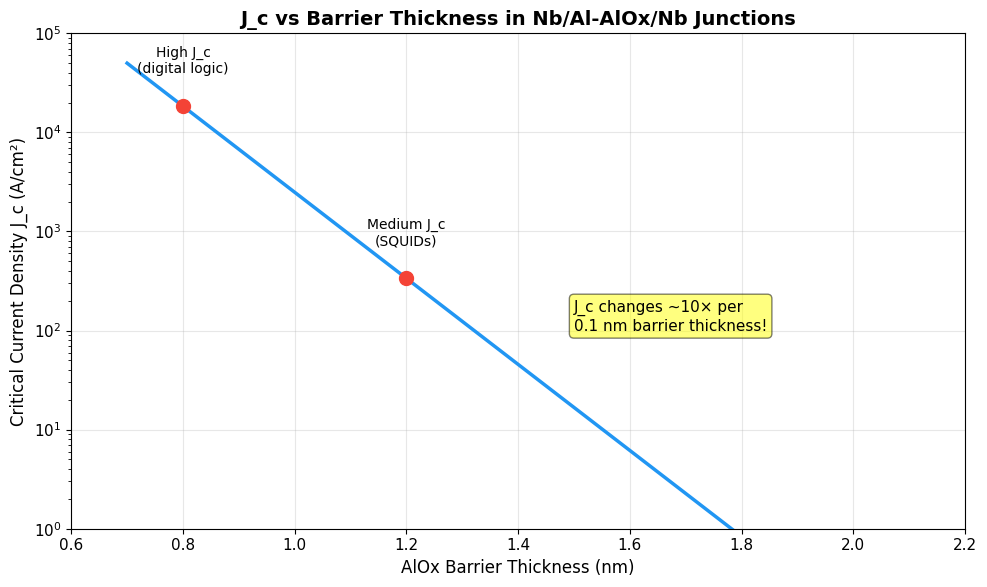

Key insight: Exquisite control of oxidation is essential for reproducible junctions.


In [8]:
# Visualize Jc vs barrier thickness relationship
fig, ax = plt.subplots(figsize=(10, 6))

# Barrier thickness range (nm)
d = np.linspace(0.7, 2.0, 100)

# Simplified tunnel model: Jc ~ exp(-2d*sqrt(2m*phi)/hbar)
# Using characteristic decay length ~ 0.1 nm for AlOx
decay_length = 0.1  # nm
Jc_0 = 50000  # A/cm² at d=0.7nm (reference)
Jc = Jc_0 * np.exp(-(d - 0.7) / decay_length)

ax.semilogy(d, Jc, color=COLORS['primary'], linewidth=2.5)

# Mark typical operating points
operating_points = [
    (0.8, 'High J_c\n(digital logic)', 'top'),
    (1.2, 'Medium J_c\n(SQUIDs)', 'top'),
    (1.9, 'Low J_c\n(qubits)', 'bottom')
]

for d_op, label, va in operating_points:
    Jc_op = Jc_0 * np.exp(-(d_op - 0.7) / decay_length)
    ax.scatter([d_op], [Jc_op], s=100, color=COLORS['danger'], zorder=5)
    y_offset = 2 if va == 'top' else 0.5
    ax.annotate(label, (d_op, Jc_op * y_offset), fontsize=10, ha='center', va='bottom')

ax.set_xlabel('AlOx Barrier Thickness (nm)', fontsize=12)
ax.set_ylabel('Critical Current Density J_c (A/cm²)', fontsize=12)
ax.set_title('J_c vs Barrier Thickness in Nb/Al-AlOx/Nb Junctions', fontsize=14, fontweight='bold')
ax.set_xlim(0.6, 2.2)
ax.set_ylim(1, 100000)
ax.grid(True, alpha=0.3)

# Annotation for exponential sensitivity
ax.annotate('J_c changes ~10× per\n0.1 nm barrier thickness!', 
            xy=(1.5, 100), fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print("Key insight: Exquisite control of oxidation is essential for reproducible junctions.")

### 3.4 J_c Control via Oxidation Parameters

Modern foundry processes achieve excellent J_c control:

| Specification | Typical Value |
|---------------|---------------|
| J_c target | 1-100 kA/cm² |
| Wafer uniformity | ±3-5% |
| Wafer-to-wafer | ±5-10% |
| Run-to-run | ±10% |

#### Process Control Variables

1. **Oxygen exposure**: Product of (pressure × time)
   - Typical: 10-1000 Pa·min
   
2. **Al layer thickness**: Affects proximization
   - Too thin: incomplete coverage
   - Too thick: reduced gap
   
3. **Base Nb quality**: Affects interface
   - Clean vacuum, low O₂ contamination
   - Epitaxial or highly textured films

---
<a id="4-comparison"></a>
# 4. Material Properties Comparison
---

### Complete LTS Material Properties Table

| Property | Symbol | Nb | NbN | NbTiN | Al | Units |
|----------|--------|-----|-----|-------|-----|-------|
| Critical temperature | T_c | 9.2 | 16 | 15+ | 1.2 | K |
| Energy gap | 2Δ | 3.0 | 5.0 | 4.8 | 0.34 | meV |
| London penetration depth | λ_L | 39 | 200 | 250 | 50 | nm |
| Coherence length | ξ_0 | 38 | 5 | 5 | 1600 | nm |
| GL parameter | κ | ~1 | 40 | 50 | ~0.03 | - |
| Type | - | II | II | II | I | - |
| Gap ratio | 2Δ/k_BT_c | 3.8 | 3.6 | 3.7 | 3.3 | - |
| Typical film resistivity | ρ_n | 5-15 | 100-300 | 100-300 | 1-5 | μΩ·cm |
| Sheet kinetic inductance | L_k | ~0.1 | ~1-5 | ~1-10 | ~0.5 | pH/□ |

In [9]:
# Function to calculate gap from Tc (BCS weak-coupling)
def calculate_gap_bcs(Tc, coupling_ratio=3.53):
    """Calculate energy gap from critical temperature using BCS theory.
    
    Parameters:
    -----------
    Tc : float
        Critical temperature in Kelvin
    coupling_ratio : float
        2Δ/(k_B*T_c) ratio (3.53 for weak coupling BCS)
        
    Returns:
    --------
    two_delta : float
        Energy gap 2Δ in meV
    """
    two_delta_eV = coupling_ratio * k_B * Tc
    return two_delta_eV * 1000  # Convert to meV

# Calculate gaps for all materials
materials_data = {
    'Nb': {'Tc': 9.2, 'gap_exp': 3.0},
    'NbN': {'Tc': 16, 'gap_exp': 5.0},
    'NbTiN': {'Tc': 15, 'gap_exp': 4.8},
    'Al': {'Tc': 1.2, 'gap_exp': 0.34}
}

print("="*70)
print("ENERGY GAP CALCULATIONS FROM T_c (BCS Theory)")
print("="*70)
print(f"{'Material':<10} {'T_c (K)':<10} {'2Δ_BCS (meV)':<15} {'2Δ_exp (meV)':<15} {'Ratio'}")
print("-"*70)

for mat, data in materials_data.items():
    gap_bcs = calculate_gap_bcs(data['Tc'])
    ratio = data['gap_exp'] / (k_B * data['Tc'] * 1000)
    print(f"{mat:<10} {data['Tc']:<10.1f} {gap_bcs:<15.2f} {data['gap_exp']:<15.2f} {ratio:.2f}")

print(f"")
print(f"Note: Ratio > 3.53 indicates stronger-than-weak coupling.")
print(f"      Nb shows moderate strong-coupling effects.")

ENERGY GAP CALCULATIONS FROM T_c (BCS Theory)
Material   T_c (K)    2Δ_BCS (meV)    2Δ_exp (meV)    Ratio
----------------------------------------------------------------------
Nb         9.2        2.80            3.00            3.78
NbN        16.0       4.87            5.00            3.63
NbTiN      15.0       4.56            4.80            3.71
Al         1.2        0.37            0.34            3.29

Note: Ratio > 3.53 indicates stronger-than-weak coupling.
      Nb shows moderate strong-coupling effects.


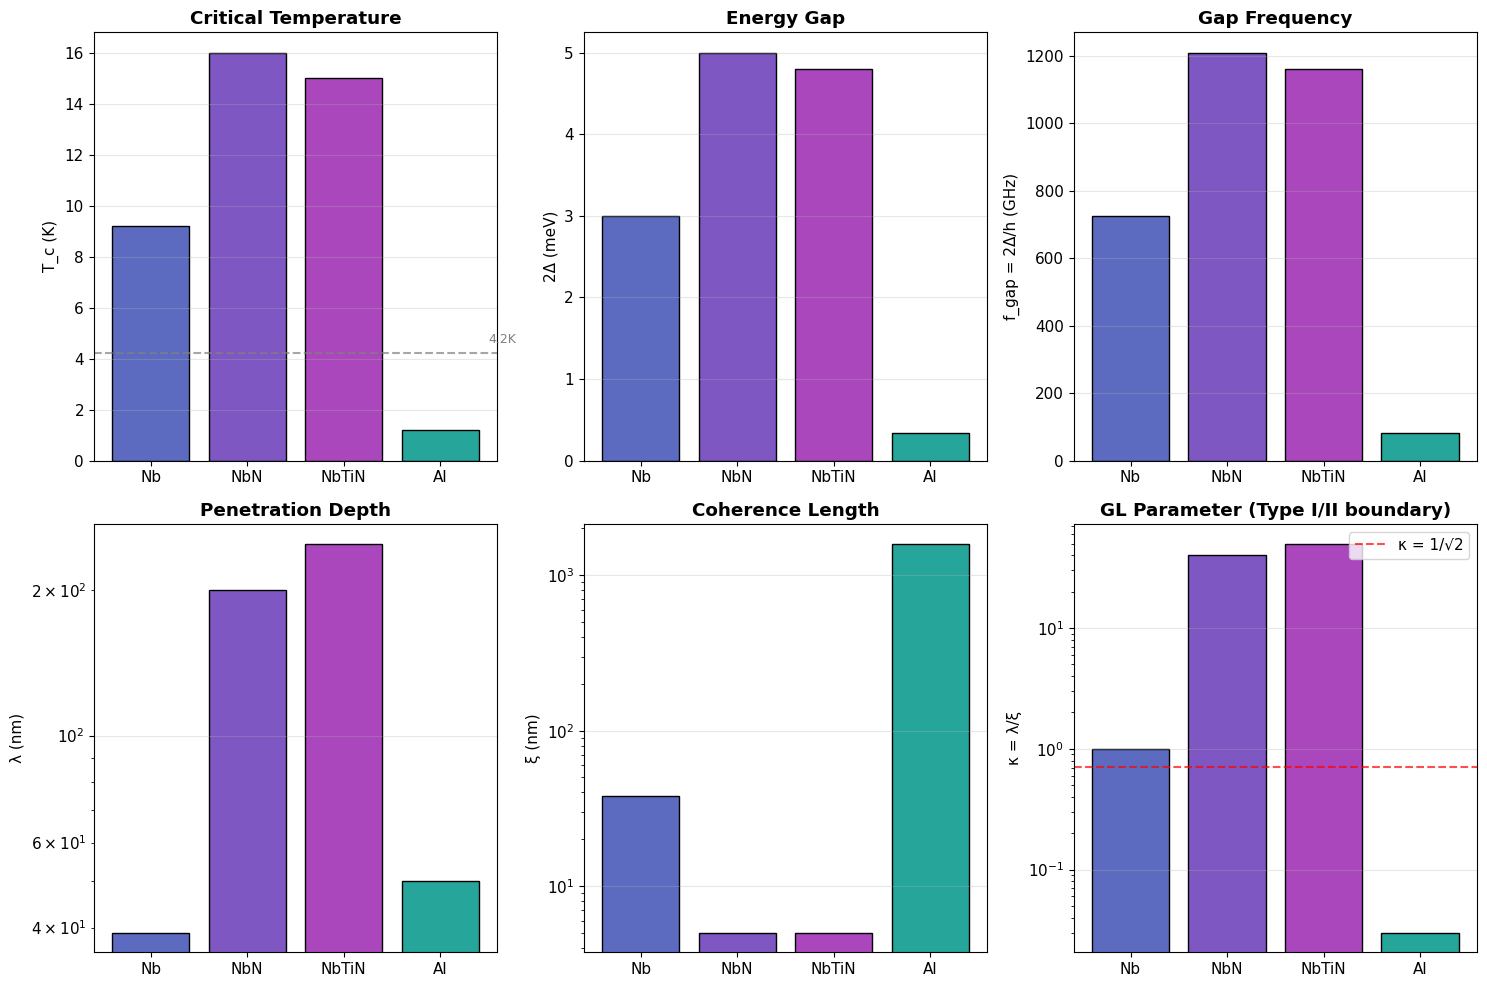


Observations:
  - NbN/NbTiN: High κ (dirty limit) → high kinetic inductance
  - Al: Very low κ (Type I) → clean superconductor
  - Nb: κ ≈ 1 (borderline Type I/II) → best for junctions


In [10]:
# Comprehensive visualization of material properties
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

materials = ['Nb', 'NbN', 'NbTiN', 'Al']
colors = [COLORS['nb'], COLORS['nbn'], COLORS['nbtin'], COLORS['al']]

# Data
Tc_values = [9.2, 16, 15, 1.2]
gap_values = [3.0, 5.0, 4.8, 0.34]
lambda_values = [39, 200, 250, 50]
xi_values = [38, 5, 5, 1600]
kappa_values = [1.0, 40, 50, 0.03]
Lk_values = [0.1, 3, 5, 0.5]  # pH/square

# 1. Tc
ax = axes[0, 0]
bars = ax.bar(materials, Tc_values, color=colors, edgecolor='black')
ax.axhline(4.2, color='gray', linestyle='--', alpha=0.7)
ax.text(3.5, 4.6, '4.2K', fontsize=9, color='gray')
ax.set_ylabel('T_c (K)')
ax.set_title('Critical Temperature', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 2. Energy Gap
ax = axes[0, 1]
ax.bar(materials, gap_values, color=colors, edgecolor='black')
ax.set_ylabel('2Δ (meV)')
ax.set_title('Energy Gap', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 3. Gap Frequency
ax = axes[0, 2]
gap_freq = [g * e * 1e-3 / h / 1e9 for g in gap_values]  # Convert meV to GHz
ax.bar(materials, gap_freq, color=colors, edgecolor='black')
ax.set_ylabel('f_gap = 2Δ/h (GHz)')
ax.set_title('Gap Frequency', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 4. Penetration depth (log)
ax = axes[1, 0]
ax.bar(materials, lambda_values, color=colors, edgecolor='black')
ax.set_ylabel('λ (nm)')
ax.set_title('Penetration Depth', fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# 5. Coherence length (log)
ax = axes[1, 1]
ax.bar(materials, xi_values, color=colors, edgecolor='black')
ax.set_ylabel('ξ (nm)')
ax.set_title('Coherence Length', fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# 6. GL parameter kappa (log)
ax = axes[1, 2]
ax.bar(materials, kappa_values, color=colors, edgecolor='black')
ax.axhline(1/np.sqrt(2), color='red', linestyle='--', alpha=0.7, label='κ = 1/√2')
ax.set_ylabel('κ = λ/ξ')
ax.set_title('GL Parameter (Type I/II boundary)', fontweight='bold')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("")
print("Observations:")
print("  - NbN/NbTiN: High κ (dirty limit) → high kinetic inductance")
print("  - Al: Very low κ (Type I) → clean superconductor")
print("  - Nb: κ ≈ 1 (borderline Type I/II) → best for junctions")

In [11]:
# Calculate characteristic frequencies and timescales
print("="*70)
print("CHARACTERISTIC FREQUENCIES AND TIMESCALES")
print("="*70)
print(f"")
print(f"{'Material':<10} {'f_gap (GHz)':<15} {'τ_gap (ps)':<15} {'Application'}")
print("-"*70)

applications = ['Digital logic', 'Photon detectors', 'KIDs, TWPAs', 'Qubits']

for mat, gap, app in zip(materials, gap_values, applications):
    f_gap = gap * 1e-3 * e / h  # Hz
    tau_gap = 1 / f_gap  # s
    print(f"{mat:<10} {f_gap/1e9:<15.0f} {tau_gap*1e12:<15.2f} {app}")

print(f"")
print(f"f_gap sets the maximum switching frequency for SFQ logic.")
print(f"τ_gap is related to intrinsic junction response time.")

CHARACTERISTIC FREQUENCIES AND TIMESCALES

Material   f_gap (GHz)     τ_gap (ps)      Application
----------------------------------------------------------------------
Nb         725             1.38            Digital logic
NbN        1209            0.83            Photon detectors
NbTiN      1161            0.86            KIDs, TWPAs
Al         82              12.16           Qubits

f_gap sets the maximum switching frequency for SFQ logic.
τ_gap is related to intrinsic junction response time.


---
<a id="5-hts"></a>
# 5. High-Temperature Superconductors (HTS)
---

High-temperature superconductors (T_c > 30 K) offer the tantalizing prospect of operation at liquid nitrogen temperature (77 K) or above, but face significant challenges for electronics.

### 5.1 Key HTS Materials

| Material | Formula | T_c (K) | Structure | Discovered |
|----------|---------|---------|-----------|------------|
| YBCO | YBa₂Cu₃O₇-δ | **93** | Cuprate perovskite | 1987 |
| BSCCO-2212 | Bi₂Sr₂CaCu₂O₈ | **85** | Cuprate | 1988 |
| BSCCO-2223 | Bi₂Sr₂Ca₂Cu₃O₁₀ | **110** | Cuprate | 1988 |
| HgBaCaCuO | HgBa₂Ca₂Cu₃O₈ | **133** | Cuprate | 1993 |
| MgB₂ | MgB₂ | **39** | Simple diboride | 2001 |

### The Cuprate Revolution

The 1986-87 discovery of cuprate superconductors revolutionized the field:
- **Bednorz & Müller** (1986): La-Ba-Cu-O at 30 K
- **Wu, Chu et al.** (1987): YBCO at 93 K → above liquid N₂!

For the first time, superconductivity was possible without expensive liquid helium.

### 5.2 Why HTS is Challenging for Electronics

Despite high T_c, cuprate HTS materials face fundamental obstacles for electronics:

#### 1. D-Wave Pairing Symmetry

Unlike conventional s-wave superconductors, cuprates have **d-wave symmetry**:

| Property | S-wave (Nb) | D-wave (YBCO) |
|----------|-------------|---------------|
| Gap symmetry | Isotropic | Nodes in gap |
| Gap value | Uniform Δ | Δ(θ) = Δ₀ cos(2θ) |
| Quasiparticles | Exponentially suppressed | Present at nodes |
| Junction quality | High | Highly variable |

The **nodes** (directions where Δ = 0) mean:
- Always low-energy excitations present
- Junctions have subgap leakage
- Coherent devices are harder to make

#### 2. Grain Boundary Problems

- YBCO is **anisotropic**: superconductivity primarily in CuO₂ planes
- Grain boundaries act as **weak links**
- J_c drops exponentially with misorientation angle
- Requires **epitaxial** films on special substrates

#### 3. Short Coherence Length

| Material | ξ_ab (nm) | ξ_c (nm) | Implications |
|----------|-----------|----------|-------------|
| YBCO | 1.5 | 0.3 | < 1 unit cell! |
| Nb | 38 | 38 | Many unit cells |

- Extremely sensitive to atomic-scale defects
- Tunnel barriers must be perfect over ~1 nm scale
- Reproducibility is poor

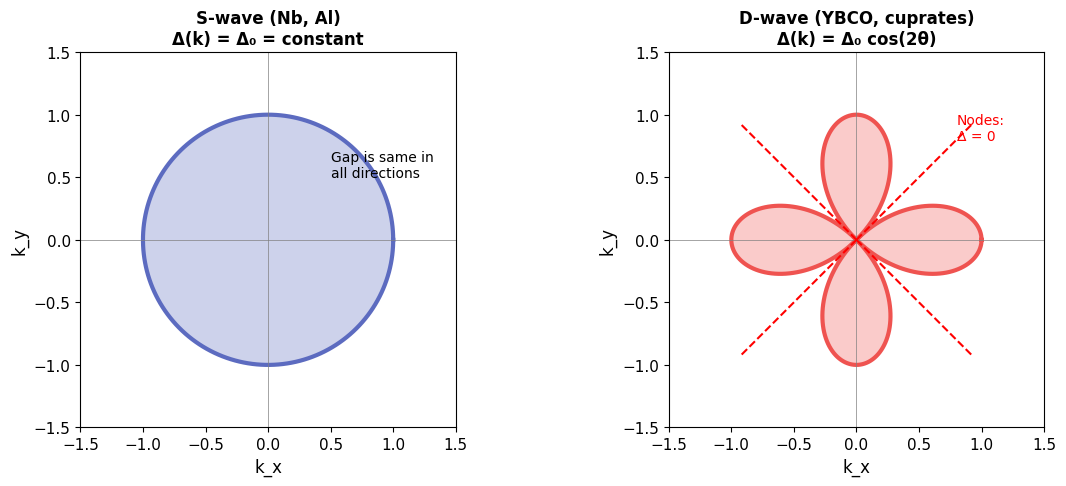

D-wave gap nodes → always quasiparticles present → worse junction quality


In [12]:
# Visualize d-wave vs s-wave gap symmetry
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

theta = np.linspace(0, 2*np.pi, 360)

# S-wave (isotropic)
ax = axes[0]
Delta_s = np.ones_like(theta)  # Constant gap
ax.plot(Delta_s * np.cos(theta), Delta_s * np.sin(theta), 
        color=COLORS['nb'], linewidth=3)
ax.fill(Delta_s * np.cos(theta), Delta_s * np.sin(theta), 
        color=COLORS['nb'], alpha=0.3)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('k_x', fontsize=12)
ax.set_ylabel('k_y', fontsize=12)
ax.set_title('S-wave (Nb, Al)\nΔ(k) = Δ₀ = constant', fontsize=12, fontweight='bold')
ax.annotate('Gap is same in\nall directions', xy=(0.5, 0.5), fontsize=10)

# D-wave (nodes)
ax = axes[1]
Delta_d = np.abs(np.cos(2 * theta))  # |cos(2θ)|, d-wave symmetry
ax.plot(Delta_d * np.cos(theta), Delta_d * np.sin(theta), 
        color=COLORS['hts'], linewidth=3)
ax.fill(Delta_d * np.cos(theta), Delta_d * np.sin(theta), 
        color=COLORS['hts'], alpha=0.3)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('k_x', fontsize=12)
ax.set_ylabel('k_y', fontsize=12)
ax.set_title('D-wave (YBCO, cuprates)\nΔ(k) = Δ₀ cos(2θ)', fontsize=12, fontweight='bold')

# Mark nodes
node_angles = [np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4]
for angle in node_angles:
    ax.plot([0, 1.3*np.cos(angle)], [0, 1.3*np.sin(angle)], 'r--', linewidth=1.5)
ax.annotate('Nodes:\nΔ = 0', xy=(0.8, 0.8), fontsize=10, color='red')

plt.tight_layout()
plt.show()

print("D-wave gap nodes → always quasiparticles present → worse junction quality")

### 5.3 Current Status of HTS Electronics

Despite challenges, some HTS electronics have been demonstrated:

| Application | Status | Performance |
|-------------|--------|-------------|
| RSFQ circuits | Lab demos | < 100 junctions |
| SQUIDs | Commercial | Geophysics, biomagnetism |
| Microwave filters | Commercial | Telecom base stations |
| Cables/fault limiters | Deployed | Power grid applications |

**Key limitation**: Junction reproducibility
- Best YBCO junctions: ~10% spread in I_c
- Nb junctions: ~3% spread
- Large circuits require ~1% → difficult with HTS

### MgB₂: A Simpler HTS Alternative

MgB₂ (T_c = 39 K) offers some advantages:
- **S-wave** pairing (like Nb)
- **Simple crystal structure**
- Two-gap superconductivity (σ and π bands)

Challenges:
- Reactive, oxidizes in air
- Thin film quality still maturing
- Not yet competitive with Nb for electronics

---
<a id="6-selection"></a>
# 6. Material Selection Criteria
---

Choosing the right superconducting material depends on the application:

### Decision Matrix

| Application | Material Choice | Key Requirement | Why This Material |
|-------------|-----------------|-----------------|-------------------|
| **Josephson junctions** | Nb/Al-AlOx/Nb | Reproducible I_c | Mature trilayer process |
| **Superconducting qubits** | Al | Low TLS loss | Clean AlOx interface |
| **Photon detectors (SNSPDs)** | NbN/NbTiN | High L_k, fast reset | Disordered thin films |
| **Kinetic inductance detectors** | NbTiN | Tunable L_k | Controllable composition |
| **Digital logic (SFQ/AQFP)** | Nb | Speed, reproducibility | Best I_cR_n, mature fab |
| **High-field magnets** | NbTi, Nb₃Sn | High H_c2 | Strong pinning |
| **RF cavities** | Nb | Low surface resistance | Very pure bulk material |

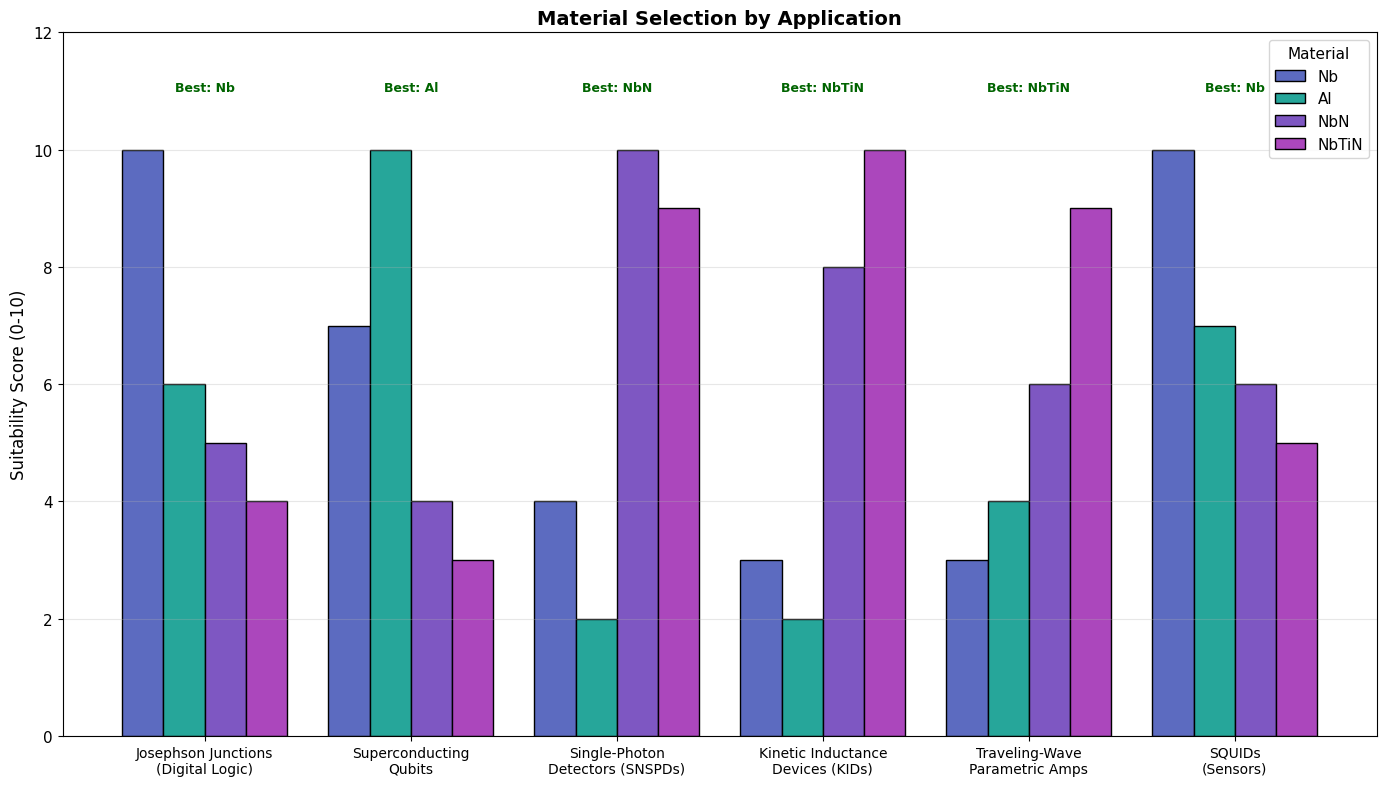

In [13]:
# Visualize application-material mapping
fig, ax = plt.subplots(figsize=(14, 8))

# Application data
applications = [
    'Josephson Junctions\n(Digital Logic)',
    'Superconducting\nQubits',
    'Single-Photon\nDetectors (SNSPDs)',
    'Kinetic Inductance\nDevices (KIDs)',
    'Traveling-Wave\nParametric Amps',
    'SQUIDs\n(Sensors)'
]

# Score each material for each application (0-10)
material_scores = {
    'Nb': [10, 7, 4, 3, 3, 10],
    'Al': [6, 10, 2, 2, 4, 7],
    'NbN': [5, 4, 10, 8, 6, 6],
    'NbTiN': [4, 3, 9, 10, 9, 5]
}

x = np.arange(len(applications))
width = 0.2

for i, (mat, scores) in enumerate(material_scores.items()):
    color = {'Nb': COLORS['nb'], 'Al': COLORS['al'], 'NbN': COLORS['nbn'], 'NbTiN': COLORS['nbtin']}[mat]
    bars = ax.bar(x + i*width, scores, width, label=mat, color=color, edgecolor='black')

ax.set_ylabel('Suitability Score (0-10)', fontsize=12)
ax.set_title('Material Selection by Application', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(applications, fontsize=10)
ax.legend(title='Material', loc='upper right')
ax.set_ylim(0, 12)
ax.grid(True, alpha=0.3, axis='y')

# Add "BEST" markers
best_materials = ['Nb', 'Al', 'NbN', 'NbTiN', 'NbTiN', 'Nb']
for i, best in enumerate(best_materials):
    ax.annotate(f'Best: {best}', (i + width*1.5, 11), ha='center', fontsize=9, 
                fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

### 6.1 For Josephson Junctions: Nb/Al-AlOx/Nb

**Requirements:**
- Reproducible critical current
- High I_cR_n product
- Low subgap leakage
- Scalable fabrication

**Why Nb/Al-AlOx/Nb wins:**
- Self-limiting oxide → reproducible I_c
- Large Nb gap → high I_cR_n (~1.9 mV)
- Mature trilayer process
- Foundry availability

### 6.2 For Qubits: Aluminum

**Requirements:**
- Minimal TLS (two-level system) defects
- Long coherence times
- Reproducible junctions
- Compatible with dilution refrigerators

**Why Al wins:**
- AlOx has lowest known TLS density
- Long ξ averages over defects
- Shadow evaporation gives reproducible junctions
- T_c = 1.2 K is fine at 10-20 mK operation

### 6.3 For Photon Detectors: NbN/NbTiN

**Requirements:**
- High kinetic inductance
- Fast energy relaxation
- Thin film capability
- Wide spectral response

**Why NbN/NbTiN win:**
- High L_k from disorder
- Fast electron-phonon coupling (~10 ps)
- 4-10 nm films give optimal detection
- Large gap → photon detection to ~4 μm

### 6.4 For Digital Logic: Niobium

**Requirements:**
- High-speed switching
- Reproducible junctions (>10,000 per chip)
- Multilayer interconnects
- Proven reliability

**Why Nb wins:**
- Best I_cR_n for speed
- ±3-5% I_c uniformity achievable
- 10+ layer processes available
- Decades of development

In [14]:
# Summary table of selection criteria
print("="*80)
print("MATERIAL SELECTION SUMMARY")
print("="*80)
print(f"")
print(f"{'Application':<30} {'Material':<15} {'Key Property':<35}")
print("-"*80)

selections = [
    ('Josephson junctions', 'Nb/Al-AlOx/Nb', 'Reproducible Ic, high IcRn'),
    ('Superconducting qubits', 'Al', 'Low TLS, long coherence length'),
    ('SNSPDs', 'NbN', 'High Lk, fast electron-phonon'),
    ('Kinetic inductance devices', 'NbTiN', 'Tunable Lk via composition'),
    ('Digital logic (SFQ/AQFP)', 'Nb', 'Speed, process maturity'),
    ('SQUIDs', 'Nb', 'Junction quality, low noise'),
]

for app, mat, key_prop in selections:
    print(f"{app:<30} {mat:<15} {key_prop:<35}")

print(f"")
print(f"Bottom line: Nb is the default; specialized apps use Al, NbN, or NbTiN.")

MATERIAL SELECTION SUMMARY

Application                    Material        Key Property                       
--------------------------------------------------------------------------------
Josephson junctions            Nb/Al-AlOx/Nb   Reproducible Ic, high IcRn         
Superconducting qubits         Al              Low TLS, long coherence length     
SNSPDs                         NbN             High Lk, fast electron-phonon      
Kinetic inductance devices     NbTiN           Tunable Lk via composition         
Digital logic (SFQ/AQFP)       Nb              Speed, process maturity            
SQUIDs                         Nb              Junction quality, low noise        

Bottom line: Nb is the default; specialized apps use Al, NbN, or NbTiN.


---
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); color: white; padding: 30px; margin: 20px -10px -10px -10px; border-radius: 15px 15px 0 0; text-align: center;">

## Summary

### Key Materials for SCE

- **Nb** (T_c = 9.2 K, 2Δ = 3.0 meV): Digital logic, JJs, SQUIDs
- **NbN** (T_c = 16 K, 2Δ = 5.0 meV): Photon detectors
- **NbTiN** (T_c = 15 K, 2Δ = 4.8 meV): KIDs, TWPAs
- **Al** (T_c = 1.2 K, 2Δ = 0.34 meV): Qubits

### Why Nb Dominates

- Highest elemental T_c → large thermal margin at 4.2 K
- Mature Nb/Al-AlOx/Nb trilayer → reproducible junctions
- Excellent I_cR_n (~1.9 mV) → fast switching
- Chemical stability → robust fabrication

### The Nb/Al-AlOx/Nb Trilayer

- Al wetting layer (6-8 nm) enables self-limiting oxidation
- Barrier thickness (0.8-1.9 nm) controls J_c
- Proximity effect makes Al superconducting
- Standard process for all Josephson junction electronics

### Key Numbers to Remember

- **Nb T_c**: 9.2 K
- **Nb energy gap 2Δ**: 3.0 meV
- **Nb I_cR_n product**: ~1.8 mV
- **Al coherence length ξ**: 1600 nm
- **Typical AlOx barrier**: 0.8-1.9 nm

### Next Session
**Josephson Junctions** — The fundamental device of superconducting electronics

</div>